In [1]:
!pip install pandas sqlalchemy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
import pandas as pd
from sqlalchemy import create_engine

# Creiamo il dataset geologico ispirato a DataCamp
data_pozzi = {
    'id_pozzo': range(1, 11),
    'uso_idrico': ['Potabile', 'Potabile', 'Irriguo', 'Potabile', 'Industriale', 'Potabile', 'Potabile', 'Potabile', 'Irriguo', 'Potabile'],
    'localita': ['Sito A', 'Sito B', 'Sito C', 'Sito D', 'Sito E', 'Sito F', 'Sito G', 'Sito H', 'Sito I', 'Sito J'],
    'profondita': [10, 25, 10, 50, 25, 50, 10, 25, 50, 50], # La nostra variabile "Stay"
    'ferro_ppm': [0.12, 0.45, 0.08, 0.55, 1.20, 0.60, 0.15, 0.40, 0.88, 0.58],
    'conducibilita_ms': [350, 420, 310, 580, 850, 600, 360, 415, 720, 595],
    'ph': [7.2, 6.8, 7.5, 6.5, 6.2, 6.4, 7.1, 6.9, 6.3, 6.6]  
}

df_pozzi = pd.DataFrame(data_pozzi)

# Creiamo il motore SQL in memoria (senza password!)
engine = create_engine('sqlite://')
df_pozzi.to_sql('monitoraggio_pozzi', engine, index=False)

print("Dataset 'monitoraggio_pozzi' caricato con successo!")
df_pozzi.head(10)


Dataset 'monitoraggio_pozzi' caricato con successo!


,id_pozzo,uso_idrico,localita,profondita,ferro_ppm,conducibilita_ms,ph
0,1,Potabile,Sito A,10,0.12,350,7.2
1,2,Potabile,Sito B,25,0.45,420,6.8
2,3,Irriguo,Sito C,10,0.08,310,7.5
3,4,Potabile,Sito D,50,0.55,580,6.5
4,5,Industriale,Sito E,25,1.20,850,6.2
5,6,Potabile,Sito F,50,0.60,600,6.4
6,7,Potabile,Sito G,10,0.15,360,7.1
7,8,Potabile,Sito H,25,0.40,415,6.9
8,9,Irriguo,Sito I,50,0.88,720,6.3
9,10,Potabile,Sito J,50,0.58,595,6.6


# Progetto A: Analisi Idrogeologica della Qualità Idrica
## Studio dell'influenza della profondità sui parametri chimico-fisici

**Obiettivo:** Determinare come la profondità di perforazione impatti la concentrazione di ferro, la conducibilità e il pH nei pozzi classificati come 'Potabili'.

### Schema dei dati:
* `profondita`: Variabile indipendente (espressa in metri).
* `ferro_ppm`: Concentrazione di ferro (parti per milione).
* `conducibilita_ms`: Conducibilità elettrica (mS/cm).
* `ph`: Misura dell'acidità/basicità dell'acqua.

In [5]:
# Query SQL per l'aggregazione dei dati per profondità
query_geologica = """
SELECT 
    profondita, 
    COUNT(*) AS conteggio_pozzi,
    ROUND(AVG(ferro_ppm), 2) AS media_ferro,
    ROUND(AVG(conducibilita_ms), 2) AS media_conducibilita,
    ROUND(AVG(ph), 2) AS media_ph
FROM monitoraggio_pozzi
WHERE uso_idrico = 'Potabile'
GROUP BY profondita
ORDER BY profondita DESC;
"""

# Esecuzione tramite Pandas
risultato = pd.read_sql_query(query_geologica, engine)
risultato

,profondita,conteggio_pozzi,media_ferro,media_conducibilita,media_ph
0,50,3,0.58,591.67,6.50
1,25,2,0.43,417.50,6.85
2,10,2,0.14,355.00,7.15


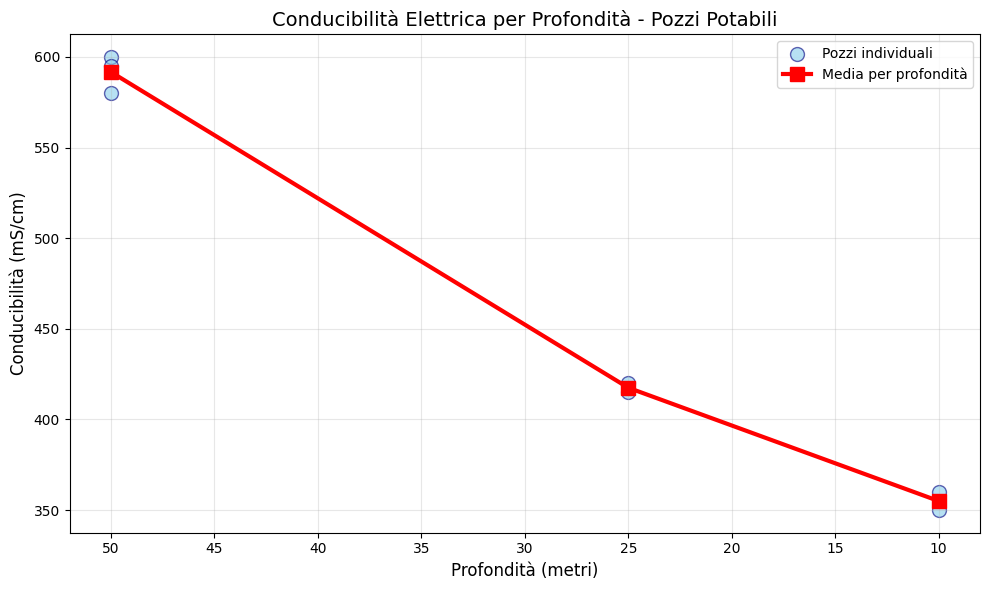

In [6]:
# Cella per il grafico - UNA SOLA CELLA
import matplotlib.pyplot as plt  # Si può importare anche qui, non serve all'inizio
import pandas as pd 

# Recupera TUTTI i dati dei pozzi potabili (non solo le medie)
query_tutti = """
SELECT profondita, conducibilita_ms
FROM monitoraggio_pozzi
WHERE uso_idrico = 'Potabile'
ORDER BY profondita;
"""
dati_completi = pd.read_sql_query(query_tutti, engine)

# Crea il grafico
plt.figure(figsize=(10, 6))

# Punti individuali (dispersione)
plt.scatter(dati_completi['profondita'], dati_completi['conducibilita_ms'], 
            alpha=0.6, s=100, color='skyblue', edgecolor='navy', 
            label='Pozzi individuali')

# Linea delle medie (usa risultato dalla query precedente)
plt.plot(risultato['profondita'], risultato['media_conducibilita'], 
         marker='s', linewidth=3, markersize=10, color='red',
         label='Media per profondità')

plt.title('Conducibilità Elettrica per Profondità - Pozzi Potabili', fontsize=14)
plt.xlabel('Profondità (metri)', fontsize=12)
plt.ylabel('Conducibilità (mS/cm)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()  # Profondità maggiore a sinistra
plt.tight_layout()
plt.show()